In [1]:
! pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/adityush/eczema2")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: yasir90
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/adityush/eczema2


100%|██████████| 203M/203M [00:00<00:00, 1.00GB/s]


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [4]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [5]:
train_data = datagen.flow_from_directory(
    "/content/eczema2/dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

Found 2500 images belonging to 2 classes.


In [6]:
val_data = datagen.flow_from_directory(
    "/content/eczema2/dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 623 images belonging to 2 classes.


In [7]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [8]:
for layer in base_model.layers:
    layer.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

predictions = Dense(2, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 73s 745ms/step - accuracy: 0.6393 - loss: 0.6440 - val_accuracy: 0.9326 - val_loss: 0.3513
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 569ms/step - accuracy: 0.8444 - loss: 0.3964 - val_accuracy: 0.9567 - val_loss: 0.2639
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 574ms/step - accuracy: 0.8528 - loss: 0.3872 - val_accuracy: 0.9518 - val_loss: 0.2233
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 555ms/step - accuracy: 0.8692 - loss: 0.3332 - val_accuracy: 0.9502 - val_loss: 0.2395
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 570ms/step - accuracy: 0.8683 - loss: 0.3449 - val_accuracy: 0.9518 - val_loss: 0.2138
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 554ms/step - accuracy: 0.8844 - loss: 0.3116 - val_accuracy: 0.9486 - val_loss: 0.2187
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 568ms/step - accuracy: 0.8752 - loss: 0.3347 - val_accuracy: 0.9454 - val_loss: 0.1977
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 568ms/step - accuracy: 0.8925 - loss: 0.3014 - val_accu

In [13]:
loss, accuracy = model.evaluate(val_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 488ms/step - accuracy: 0.9609 - loss: 0.1602
Test Loss: 0.15887455642223358
Test Accuracy: 0.966292142868042


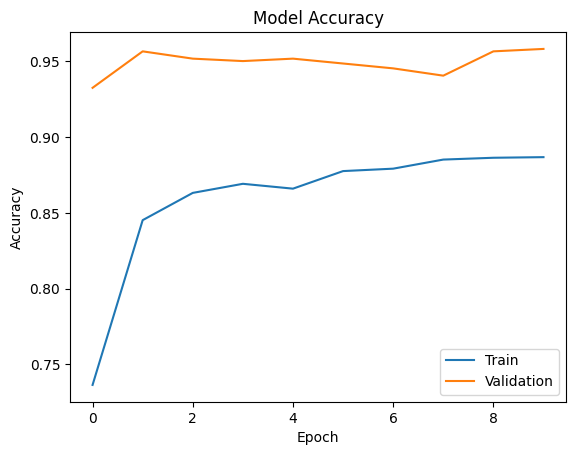

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

In [14]:
model.save("eczema_resnet50_model.h5")

In [17]:
print(train_data.class_indices)

{'Eczema': 0, 'Normal': 1}


In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/eczema2/dataset/Eczema/eczema-asteatotic-1.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

eczema_prob = prediction[0][0]
normal_prob = prediction[0][1]

print("Eczema probability:", eczema_prob)
print("Normal probability:", normal_prob)

if eczema_prob > normal_prob:
    print("Prediction: Eczema")
else:
    print("Prediction: Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Eczema probability: 0.9663913
Normal probability: 0.033608668
Prediction: Eczema


In [24]:
import json

# class indices from training generator
class_indices = train_data.class_indices

# save to json
with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("Class indices saved:", class_indices)

Class indices saved: {'Eczema': 0, 'Normal': 1}
